## Configuración inicial

In [1]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]
os.environ["PYSPARK_PYTHON"] = "python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python"

<div aling='center'>

- Fabian Martinez Rincon 18153/1
- Massera Felipe 20676/5

# Entrega 2

</div>

### Enunciado
Ha sido contratado para el análisis de uso de un videojuego online donde millones de jugadores se conectan a diario para combatir con otros jugadores. En un combate, un jugador “retador” elije un oponente (jugador “retado”) y como resultado del combate el retador obtiene un puntaje y el tiempo en segundos que duró el combate. Por cada combate, los servidores del videojuego almacena la siguiente información:

- ID_Jugador_Retador
- ID_Jugador_Retado
- Puntaje obtenido (por el retador)
- Tiempo del combate en segundos

Todos los jugadores pueden participar cuántas veces deseen y por cada combate obtienen un puntaje y también se registra el tiempo que duró el combate. Un jugador puede combatir todas las veces que quiera.

Un fragmento del dataset de este jugador podría ser:

| ID_Jug_Retador | ID_Jugador_Retado | Puntos | Tiempo |
|---------------|-------------------|--------|--------|
| 231            | 492                | 1054   | 621    |
| 231            | 492                | 2068   | 504    |
| 231            | 98                 | 789    | 302    |
| 492            | 501                | 5462   | 955    |

Semanalmente los administradores del juego quieren obtener algunas estadísticas para regalarle premios a los mejores jugadores y armar el ranking semanal. Al finalizar la semana se desea saber:
## 1) El jugador más “retador” y el jugador más “retado”.


### Explicación

1. **Carga de datos:** se lee el archivo con `sc.textFile`.
2. **Mapeo de roles:** cada línea se transforma en dos tuplas → `(RETADOR, id)` y `(RETADO, id)`.
3. **Conteo:** se agrupan las apariciones por `(rol, jugador)` y se cuentan con `reduceByKey`.
4. **Conversión a DataFrame:** se genera una tabla con columnas `rol`, `jugador`, `apariciones`.
5. **Ranking:** se usa una ventana (`Window`) para ordenar por cantidad de apariciones y quedarse con el jugador más frecuente por rol.
6. **Resultado:** se imprimen los jugadores más activos como retador y como retado.

**Dag**

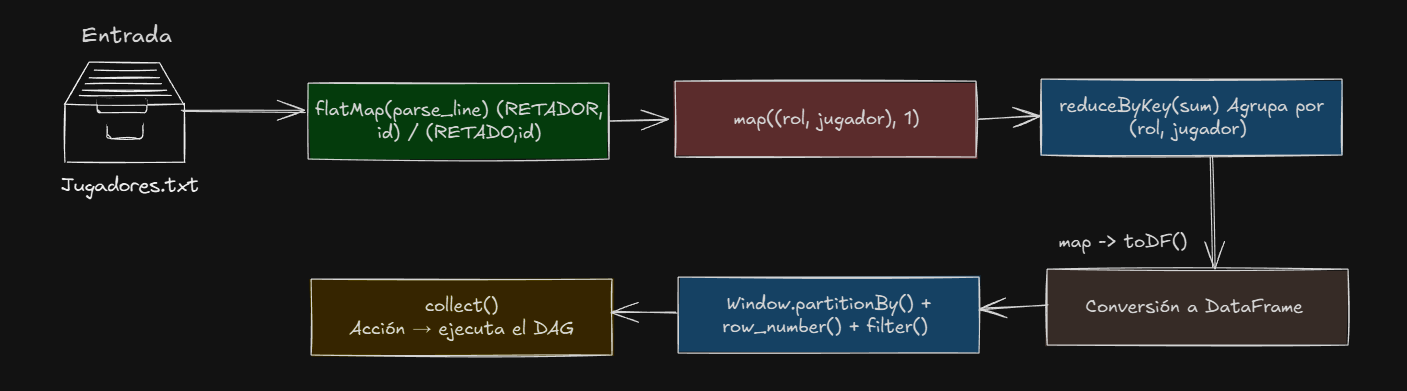


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, desc, row_number
from pyspark.sql.window import Window
import os

spark = SparkSession.builder \
    .appName("TP1 - Punto 1 (jugadores.txt)") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")

input_file = r"C:\Users\Fabian\Desktop\big-data\Datasets\TP1\input\jugadores.txt"

rdd = sc.textFile(input_file)

def parse_line(line):
    parts = line.strip().split()
    id_retador = parts[0]
    id_retado  = parts[1]
    return [("RETADOR", id_retador), ("RETADO", id_retado)]

rdd_roles = rdd.flatMap(parse_line)

conteo = (
    rdd_roles
    .map(lambda x: ((x[0], x[1]), 1))
    .reduceByKey(lambda a, b: a + b)
)
df = conteo.map(lambda x: (x[0][0], x[0][1], x[1])).toDF(["rol", "jugador", "apariciones"])

w = Window.partitionBy("rol").orderBy(desc("apariciones"))
resultado = df.withColumn("rank", row_number().over(w)).filter(col("rank") == 1)

fila_retador = resultado.filter(col("rol") == "RETADOR").collect()[0]
fila_retado  = resultado.filter(col("rol") == "RETADO").collect()[0]

print("Consulta 1:")
print(f"El jugador más 'retador': Jugador {fila_retador}")
print(f"El jugador más 'retado': Jugador {fila_retado}")

spark.stop()


Consulta 1:
El jugador más 'retador': Jugador Row(rol='RETADOR', jugador='1', apariciones=18, rank=1)
El jugador más 'retado': Jugador Row(rol='RETADO', jugador='43', apariciones=15, rank=1)


---

## 2) El jugador que más puntos obtuvo en promedio

$$
PP_i = \frac{puntaje\_total\_de\_todos\_los\_combates_i + 1}{cantidad\_de\_combates\_como\_retador_i + 1}
$$

*(el +1 en el numerador y en el denominador es para evitar divisiones por cero en el caso que un jugador no haya “retado” a nadie, en cuyo caso tendrá el puntaje mínimo de 1).*

---

### **Explicación**

Calculamos el **promedio de puntajes obtenidos por cada jugador retador** a partir del archivo `jugadores.txt`.

Primero, se leen los datos y se extraen el **ID del retador** y su **puntaje** en cada combate. Luego, se agrupan los registros por jugador utilizando `reduceByKey`, sumando los puntajes y contando la cantidad de combates.

A partir de esos valores acumulados, se calcula el **promedio de puntaje por jugador** mediante una transformación `mapValues`. Finalmente, se selecciona con `max()` al jugador con el **mayor promedio de puntaje** y se muestra el resultado en pantalla.

**Dag**

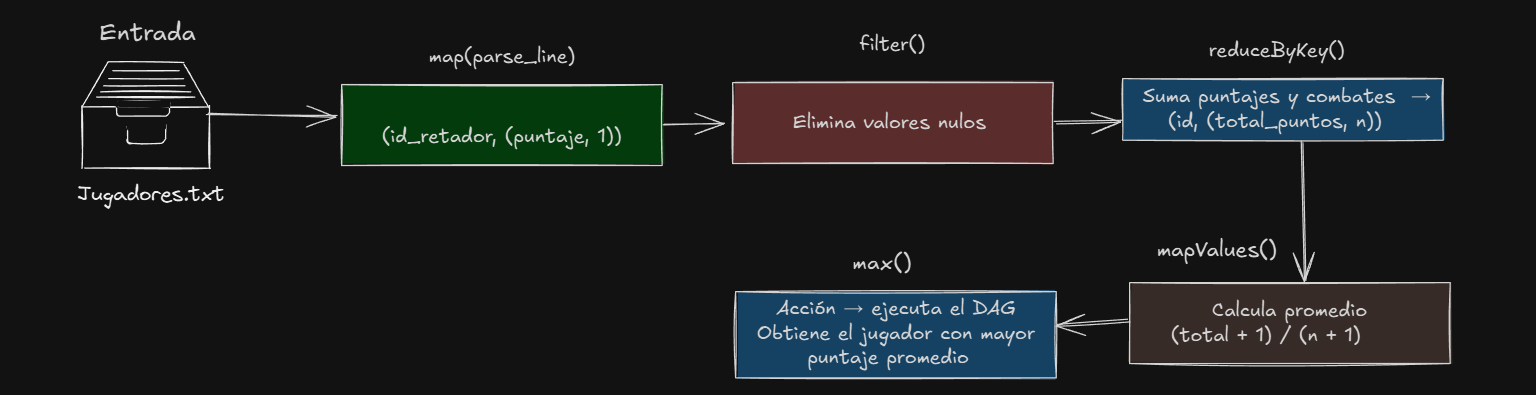


In [3]:
from pyspark.sql import SparkSession
import os

spark = SparkSession.builder \
    .appName("TP1 - Punto 2 (promedio de puntajes)") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")
input_file = r"C:\Users\Fabian\Desktop\big-data\Datasets\TP1\input\jugadores.txt"


rdd = sc.textFile(input_file)

def parse_line(line):
    parts = line.strip().split()
    id_retador = parts[0]
    puntaje = int(parts[2])
    return (id_retador, (puntaje, 1))

rdd_pares = rdd.map(parse_line).filter(lambda x: x is not None)
rdd_sum = rdd_pares.reduceByKey(
    lambda a, b: (a[0] + b[0], a[1] + b[1])
)

rdd_promedios = rdd_sum.mapValues(lambda x: (x[0] + 1) / (x[1] + 1))
mejor = rdd_promedios.max(key=lambda x: x[1])

print("Consulta 2:")
print(f"El jugador con más puntos en promedio: Jugador {mejor[0]} con {mejor[1]:.2f}")

spark.stop()


Consulta 2:
El jugador con más puntos en promedio: Jugador 53 con 3504.43


---

## 3) Todos los jugadores que “retaron” a más de **H** oponentes **distintos**

*(H es un parámetro de la consulta).*

### Explicación

Identificamos a los jugadores que **retaron a más de H oponentes distintos** (donde *H* es un valor configurable).

Primero se lee el archivo `jugadores.txt` y se extraen las parejas `(id_retador, id_retado)` de cada línea. Luego, los datos se agrupan por el ID del retador usando `groupByKey()`, obteniendo para cada jugador la lista de oponentes que enfrentó.

Se calcula cuántos **oponentes únicos** tuvo cada retador mediante `len(set(vals))`. Finalmente, se filtran aquellos jugadores cuyo número de oponentes distintos supera el umbral `H`, y se muestran sus identificadores como resultado.

**Dag**

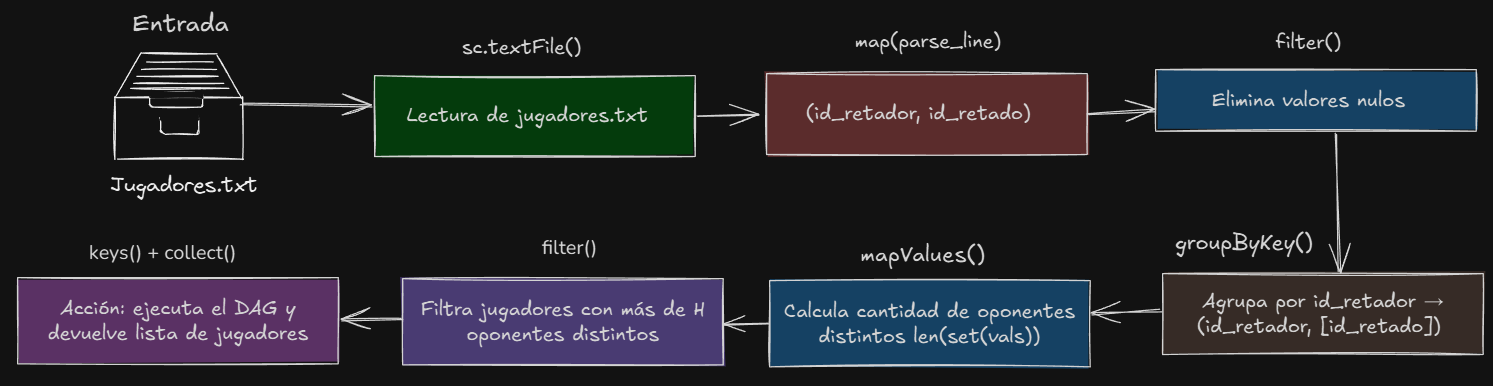


In [4]:
from pyspark.sql import SparkSession
import os
spark = SparkSession.builder \
    .appName("TP1 - Punto 3 (oponentes distintos)") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")
H = 12
input_file = r"C:\Users\Fabian\Desktop\big-data\Datasets\TP1\input\jugadores.txt"
rdd = sc.textFile(input_file)
def parse_line(line):
    parts = line.strip().split()
    id_retador = parts[0]
    id_retado  = parts[1]
    return (id_retador, id_retado)

rdd_pairs = rdd.map(parse_line).filter(lambda x: x is not None)
rdd_grouped = rdd_pairs.groupByKey()
rdd_counts = rdd_grouped.mapValues(lambda vals: len(set(vals)))
jugadores = rdd_counts.filter(lambda x: x[1] >= H).keys().collect()

print("Consulta 3:")
print(f"Con H = {H}")
print(f"Jugadores que retaron a más de {H} oponentes distintos: {jugadores}")

spark.stop()


Consulta 3:
Con H = 12
Jugadores que retaron a más de 12 oponentes distintos: ['48', '1', '65', '55']


---

### 4) El top 10 de los jugadores con mejor puntaje heroico

El puntaje **PH** de un jugador *i* se calcula como:

$$
PH_i = \alpha \left( \sum_{j=1}^{n} PH_j \cdot \frac{PP_i}{PP_j} \right) + (1 - \alpha)
$$

donde:

- *n* es la cantidad de jugadores “retados” por el jugador *i*.  
- *PH_j* es el puntaje **P** del *j*-ésimo jugador retado por *i*.  
- *PP_i* es el puntaje promedio del jugador *i*.  
- *PP_j* es el puntaje promedio del *j*-ésimo jugador retado por *i*.  
- *α* es un parámetro del algoritmo.

<details><summary>Nota sobre el cálculo del puntaje heroico (PH)</summary>

Como para calcular el puntaje **PH** de un jugador *i* previamente hay que calcular el puntaje de los jugadores a quiénes retó (y a su vez éstos pueden haber retado al jugador *i*), el cálculo se realiza de manera **iterativa**.

Se comienza asignando el mismo puntaje heroico con un valor arbitrario a todos los jugadores (**tiempo 0**).  
Con esos puntajes arbitrarios se calcula el puntaje usando la fórmula detallada para obtener los nuevos puntajes (**tiempo 1**),  
con éstos se calculan los nuevos puntajes (**tiempo 2**) y así se continúa hasta alcanzar una **convergencia en los valores**.

> 📌 Al final de este documento hay un ejemplo que explica este cálculo iterativo.

</details>

<details><summary>Implementación</summary>

Implemente la cantidad de **jobs** necesarios para resolver las cuatro consultas.  
Utilice el archivo `jugadores.txt` para realizar las pruebas *(Se ofrecen los resultados de cada consulta)*.

</details>

<details><summary>⚠️ Aclaración</summary>

Suponga que la cantidad de jugadores y de combates es **“Big Data”**.

En cada **job** planteado en la solución, piense si una función **combiner** contribuye o no para la optimización del job.  
En caso de contribuir, implemente dicha función.

</details>

### Explicación

Este programa usa PySpark para calcular el **Puntaje Heroico (PH)** de los jugadores a partir del archivo `jugadores.txt`.

Primero, en el **Job 1**, se leen los datos y se limpian las columnas para dejar todo en formato numérico (`id_retador`, `id_retado`, `puntos`, `tiempo`). Básicamente, se transforma el texto del archivo en un DataFrame listo para analizar.

En el **Job 2**, se calcula el **promedio de puntaje (PP)** de cada jugador, sumando todos sus puntos y dividiéndolos por la cantidad de combates que tuvo (con una pequeña corrección para evitar errores).

Después, en el **Job 3**, arranca la parte interesante: se calcula el **Puntaje Heroico**, que depende no solo de los puntajes del jugador, sino también de los de sus oponentes.
El código hace varias iteraciones donde va ajustando el valor del PH hasta que los resultados se estabilizan (o sea, hasta que la diferencia entre una iteración y la siguiente es muy chica).

Al final, muestra el **Top 10 de jugadores más “heroicos”**, es decir, los que tuvieron el mejor rendimiento considerando a quiénes enfrentaron y cómo les fue.

### Dag

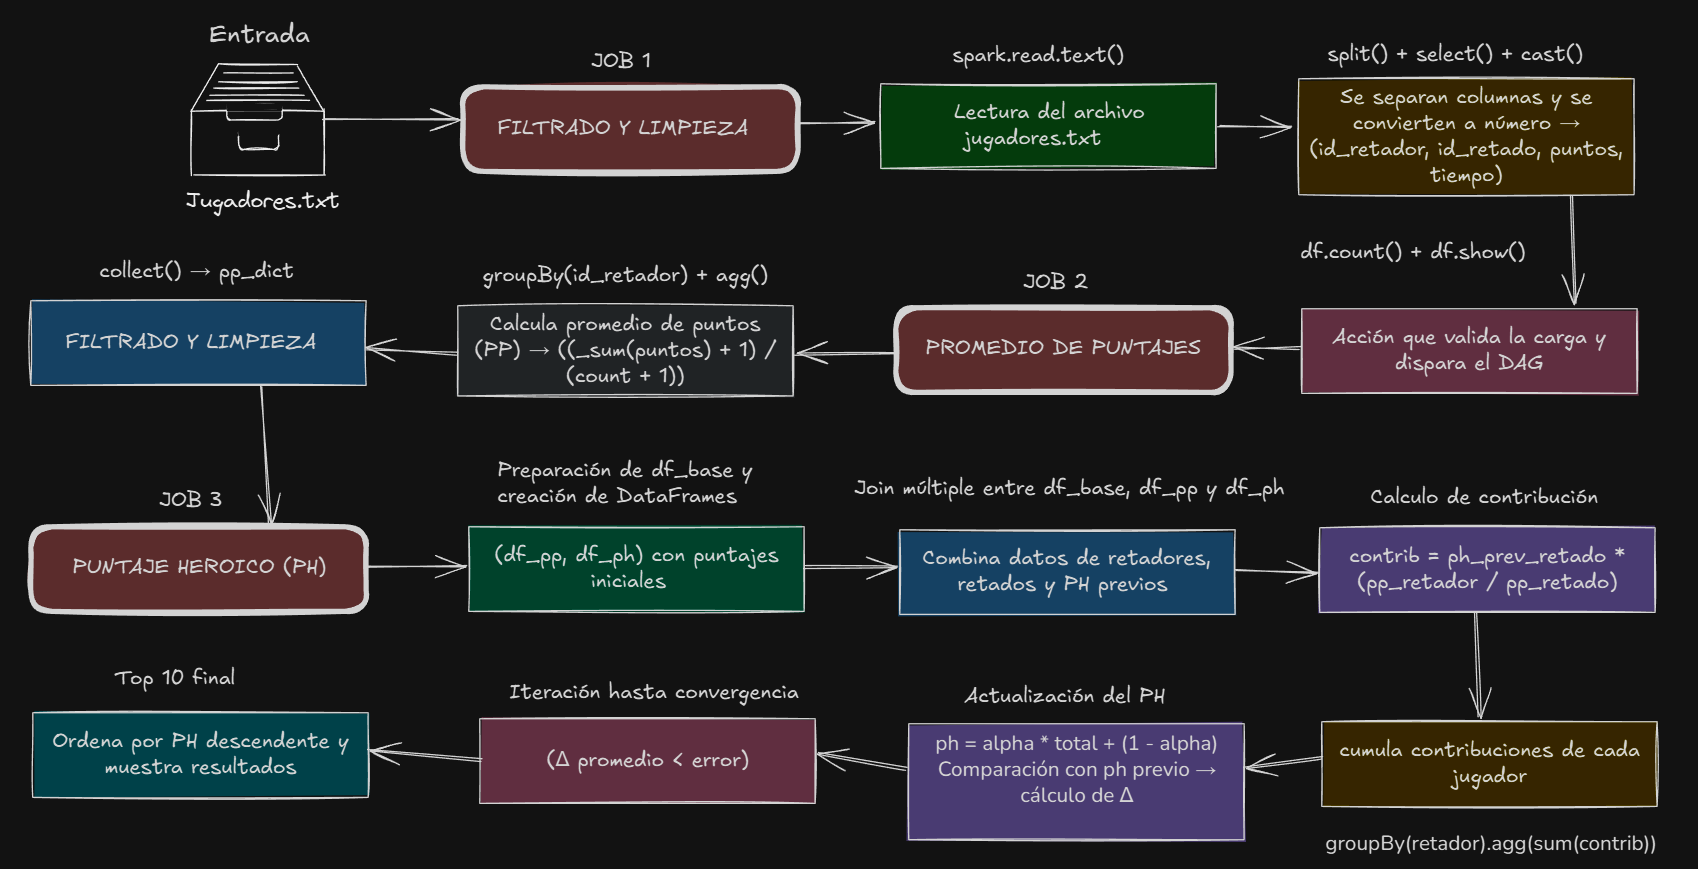


In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, trim, lit, sum as _sum, count
import os

spark = SparkSession.builder \
    .appName("TP1 - Spark pipeline (Puntaje Heroico)") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")
input_file = r"C:\Users\Fabian\Desktop\big-data\Datasets\TP1\input\jugadores.txt"

print("\n========== JOB 1: FILTRADO ==========")
df_raw = spark.read.text(input_file)

df = (
    df_raw.withColumn("cols", split(trim(col("value")), r"\s+"))
          .select(
              col("cols").getItem(0).alias("id_retador"),
              col("cols").getItem(1).alias("id_retado"),
              col("cols").getItem(2).alias("puntos"),
              col("cols").getItem(3).alias("tiempo")
          )
          .select(
              col("id_retador").cast("int"),
              col("id_retado").cast("int"),
              col("puntos").cast("double"),
              col("tiempo").cast("double")
          )
)

df.show(5, truncate=False)
print(f"[OK] Registros válidos: {df.count()}")
print("\n========== JOB 2: PROMEDIO DE PUNTAJES ==========")
df_sum = df.groupBy("id_retador").agg(
    ((_sum("puntos") + lit(1)) / (count("*") + lit(1))).alias("pp")
)
pp_dict = {int(r["id_retador"]): float(r["pp"]) for r in df_sum.collect()}
print(f"[OK] Promedios calculados: {len(pp_dict)} jugadores")

print("\n========== JOB 3: PUNTAJE HEROICO ==========")
df_base = df.selectExpr(
    "cast(id_retador as int) as retador",
    "cast(id_retado as int) as retado",
    "cast(puntos as double) as puntos",
    "cast(tiempo as double) as tiempo"
)

jugadores = set(pp_dict.keys()) | set([int(r["retado"]) for r in df_base.select("retado").distinct().collect()])
ph = {j: 1.0 for j in jugadores}

# Parámetros
alpha, error, max_iter = 0.1, 0.1, 20

for i in range(max_iter):
    df_pp = spark.createDataFrame(pp_dict.items(), ["jugador", "pp"])
    df_ph = spark.createDataFrame(ph.items(), ["jugador", "ph_prev"])

    df_join = (
        df_base
        .join(df_pp.withColumnRenamed("jugador", "retador"), on="retador", how="left")
        .withColumnRenamed("pp", "pp_retador")
        .join(df_pp.withColumnRenamed("jugador", "retado"), on="retado", how="left")
        .withColumnRenamed("pp", "pp_retado")
        .join(df_ph.withColumnRenamed("jugador", "retado"), on="retado", how="left")
        .withColumnRenamed("ph_prev", "ph_prev_retado")
        .fillna({"pp_retador": 1.0, "pp_retado": 1.0, "ph_prev_retado": 1.0})
    )

    print(f"[DEBUG] Registros join: {df_join.count()}")
    df_contrib = df_join.withColumn(
        "contrib", col("ph_prev_retado") * (col("pp_retador") / col("pp_retado"))
    ).select("retador", "contrib")

    df_sum_contrib = df_contrib.groupBy("retador").agg(_sum("contrib").alias("total"))
    print(f"[DEBUG] Jugadores con contribución: {df_sum_contrib.count()}")
    df_new_ph = df_sum_contrib.withColumn("ph", alpha * col("total") + (1 - alpha))
    nuevo_ph = {int(r["retador"]): float(r["ph"]) for r in df_new_ph.collect()}
    dif = sum(abs(nuevo_ph.get(j, 0) - ph.get(j, 0)) for j in nuevo_ph) / len(nuevo_ph)
    print(f"[INFO] promedio = {dif:.4f}")

    ph = nuevo_ph
    if dif < error:
        print(f"[INFO] Convergencia alcanzada en iteración {i+1}")
        break

print("\n========== TOP 10 FINAL ==========")
top10 = sorted(ph.items(), key=lambda x: x[1], reverse=True)[:10]
for j, p in top10:
    print(f"(Jugador = {j}, Puntaje heroico = {p:.2f})")

spark.stop()



========== JOB 1: FILTRADO ==========
+----------+---------+------+------+
|id_retador|id_retado|puntos|tiempo|
+----------+---------+------+------+
|15        |89       |707.0 |176.0 |
|28        |81       |2606.0|64.0  |
|64        |34       |4085.0|460.0 |
|9         |74       |2136.0|972.0 |
|13        |49       |4463.0|485.0 |
+----------+---------+------+------+
only showing top 5 rows

[OK] Registros válidos: 518

========== JOB 2: PROMEDIO DE PUNTAJES ==========
[OK] Promedios calculados: 100 jugadores

========== JOB 3: PUNTAJE HEROICO ==========
[DEBUG] Registros join: 518
[DEBUG] Jugadores con contribución: 100
[INFO] promedio = 54.9157
[DEBUG] Registros join: 518
[DEBUG] Jugadores con contribución: 100
[INFO] promedio = 37.6379
[DEBUG] Registros join: 518
[DEBUG] Jugadores con contribución: 100
[INFO] promedio = 24.4953
[DEBUG] Registros join: 518
[DEBUG] Jugadores con contribución: 100
[INFO] promedio = 15.1487
[DEBUG] Registros join: 518
[DEBUG] Jugadores con contribució